<a href="https://colab.research.google.com/github/sreelakshmisajeevan-854/Data-science/blob/main/Cardiographic-Data-Exploratory-Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive
import warnings
warnings.filterwarnings('ignore')
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# 1.	Data Cleaning and Preparation:

In [ ]:
df=pd.read_csv('/content/drive/MyDrive/Datasets/Cardiotocographic.csv')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2126 entries, 0 to 2125
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   LB        2105 non-null   float64
 1   AC        2106 non-null   float64
 2   FM        2126 non-null   float64
 3   UC        2126 non-null   float64
 4   DL        2126 non-null   float64
 5   DS        2105 non-null   float64
 6   DP        2105 non-null   float64
 7   ASTV      2126 non-null   float64
 8   MSTV      2126 non-null   float64
 9   ALTV      2126 non-null   float64
 10  MLTV      2105 non-null   float64
 11  Width     2105 non-null   float64
 12  Tendency  2105 non-null   float64
 13  NSP       2105 non-null   float64
dtypes: float64(14)
memory usage: 232.7 KB


In [ ]:
df

,LB,AC,FM,UC,DL,DS,DP,ASTV,MSTV,ALTV,MLTV,Width,Tendency,NSP
0,120.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,73.0,0.5,43.000000,2.4,64.0,0.999926,2.000000
1,132.000000,0.006380,0.000000,0.006380,0.003190,0.0,0.0,17.0,2.1,0.000000,10.4,130.0,0.000000,1.000000
2,133.000000,0.003322,0.000000,0.008306,0.003322,0.0,0.0,16.0,2.1,0.000000,13.4,130.0,0.000000,1.000000
3,134.000000,0.002561,0.000000,0.007742,0.002561,0.0,0.0,16.0,2.4,0.000000,23.0,117.0,1.000000,1.000000
4,131.948232,0.006515,0.000000,0.008143,0.000000,0.0,0.0,16.0,2.4,0.000000,19.9,117.0,1.000000,1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2121,140.000000,0.000000,0.961268,0.007426,0.000000,0.0,0.0,79.0,0.2,25.000000,7.2,40.0,0.000000,2.000000
2122,140.000000,0.000775,0.000000,0.006979,0.000000,0.0,0.0,78.0,0.4,22.000000,7.1,66.0,1.000000,2.000000
2123,140.000000,0.000980,0.000000,0.006863,0.000000,0.0,0.0,79.0,0.4,20.000000,6.1,67.0,1.000000,1.990464
2124,140.000000,0.000679,0.000000,0.006110,0.000000,0.0,0.0,78.0,0.4,27.000000,7.0,66.0,1.000000,2.000000


In [ ]:
for col in df.columns:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].mean())

In [ ]:
df[col].isnull().sum()


np.int64(0)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2126 entries, 0 to 2125
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   LB        2126 non-null   float64
 1   AC        2126 non-null   float64
 2   FM        2126 non-null   float64
 3   UC        2126 non-null   float64
 4   DL        2126 non-null   float64
 5   DS        2126 non-null   float64
 6   DP        2126 non-null   float64
 7   ASTV      2126 non-null   float64
 8   MSTV      2126 non-null   float64
 9   ALTV      2126 non-null   float64
 10  MLTV      2126 non-null   float64
 11  Width     2126 non-null   float64
 12  Tendency  2126 non-null   float64
 13  NSP       2126 non-null   float64
dtypes: float64(14)
memory usage: 232.7 KB


All 14 columns are stored as the float64 data type, which is appropriate for numerical data.

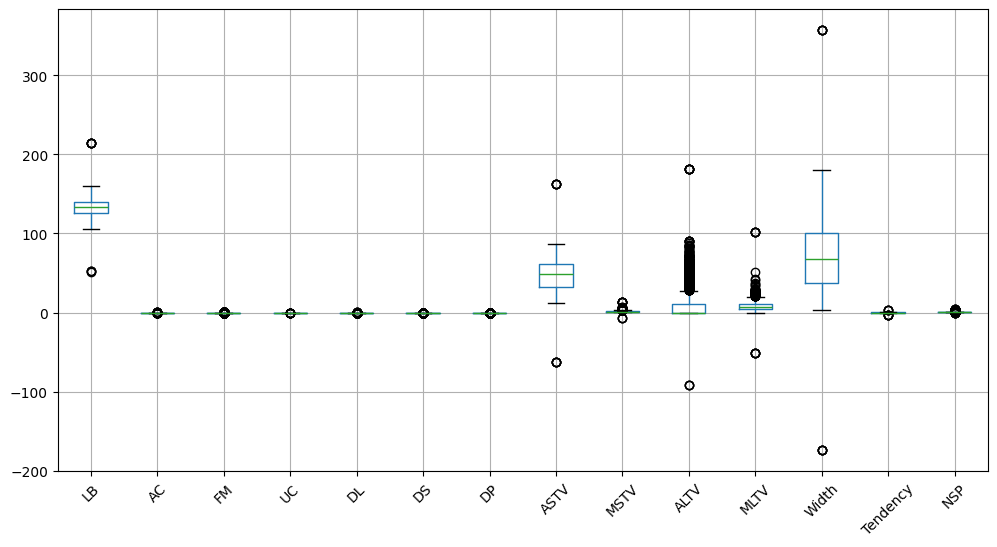

In [ ]:
df.boxplot(figsize=(12,6))
plt.xticks(rotation=45)
plt.show()

There are some outliers.Treated them using the capping technique. Values outside the lower and upper IQR limits were replaced with the corresponding boundary values.

In [ ]:
for col in df.columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[col] = df[col].clip(lower, upper)

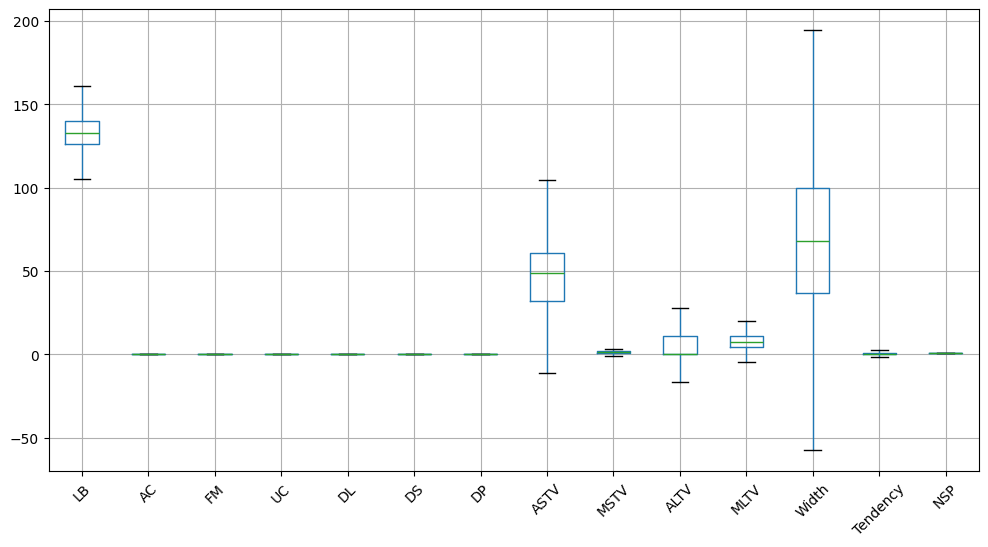

In [ ]:
df.boxplot(figsize=(12,6))
plt.xticks(rotation=45)
plt.show()

# 2.	Statistical Summary

Mean

In [ ]:
mean_df = df.mean(numeric_only=True).to_frame(name='mean')
display(mean_df)

,mean
LB,133.293725
AC,0.003147
FM,0.001568
UC,0.004362
DL,0.001770
DS,0.000000
DP,0.000000
ASTV,46.981873
MSTV,1.304644
ALTV,6.691678


Median

In [ ]:
median_df=df.median(numeric_only=True).to_frame(name='median')
display(median_df)

,median
LB,133.000000
AC,0.001668
FM,0.000000
UC,0.004484
DL,0.000000
DS,0.000000
DP,0.000000
ASTV,49.000000
MSTV,1.200000
ALTV,0.000000




*   AC, FM, DL, ALTV, and Tendency show positive skewness because their mean values are greater than their medians.




Mode

In [ ]:
mode_df=df.mode(numeric_only=True).iloc[0].to_frame(name='mode')
display(mode_df)

,mode
LB,133.0
AC,0.0
FM,0.0
UC,0.0
DL,0.0
DS,0.0
DP,0.0
ASTV,65.0
MSTV,0.5
ALTV,0.0




*   LB ,ASTV ,MSTV ,Width ,NSP have frequent values.



Standard Deviation

In [ ]:
std_dev=df.std(numeric_only=True).to_frame(name='std_deviation')
display(std_dev)

,std_deviation
LB,9.930227
AC,0.003826
FM,0.002485
UC,0.003001
DL,0.002668
DS,0.000000
DP,0.000000
ASTV,17.612745
MSTV,0.781091
ALTV,10.378400





*   LB, ASTV, Width, ALTV, and MLTV have relatively high standard deviations, indicating greater variability in their values across observations.
*   AC, FM, UC, DL, MSTV, Tendency, DS, and DP have low standard deviations, indicating that their values are closely clustered around the mean and show less variation.



Interquartile range

In [ ]:
iqr=df.quantile(0.75, numeric_only=True) - df.quantile(0.25, numeric_only=True)
iqr=iqr.to_frame(name='iqr')
display(iqr)

,iqr
FM,0.002567
UC,0.004685
DL,0.003289
ASTV,29.000000
MSTV,1.000000
ALTV,11.000000




*   Width, ASTV, LB, ALTV, and MLTV  have larger IQR values, indicating that the middle 50% of the observations are spread over a wider range. These variables show greater variability.
*   AC, FM, UC, DL, MSTV, and Tendency have smaller IQR values, indicating that the middle 50% of the observations are closely clustered, showing less variability.



Inference


*   For most variables, the mean and median are close, indicating relatively balanced distributions, while a few variables show slight skewness.
*   The standard deviation and interquartile range (IQR) reveal that some variables have greater variability.
*   A few variables exhibit little or no variation.





# 3.	Data Visualization

#Histogram

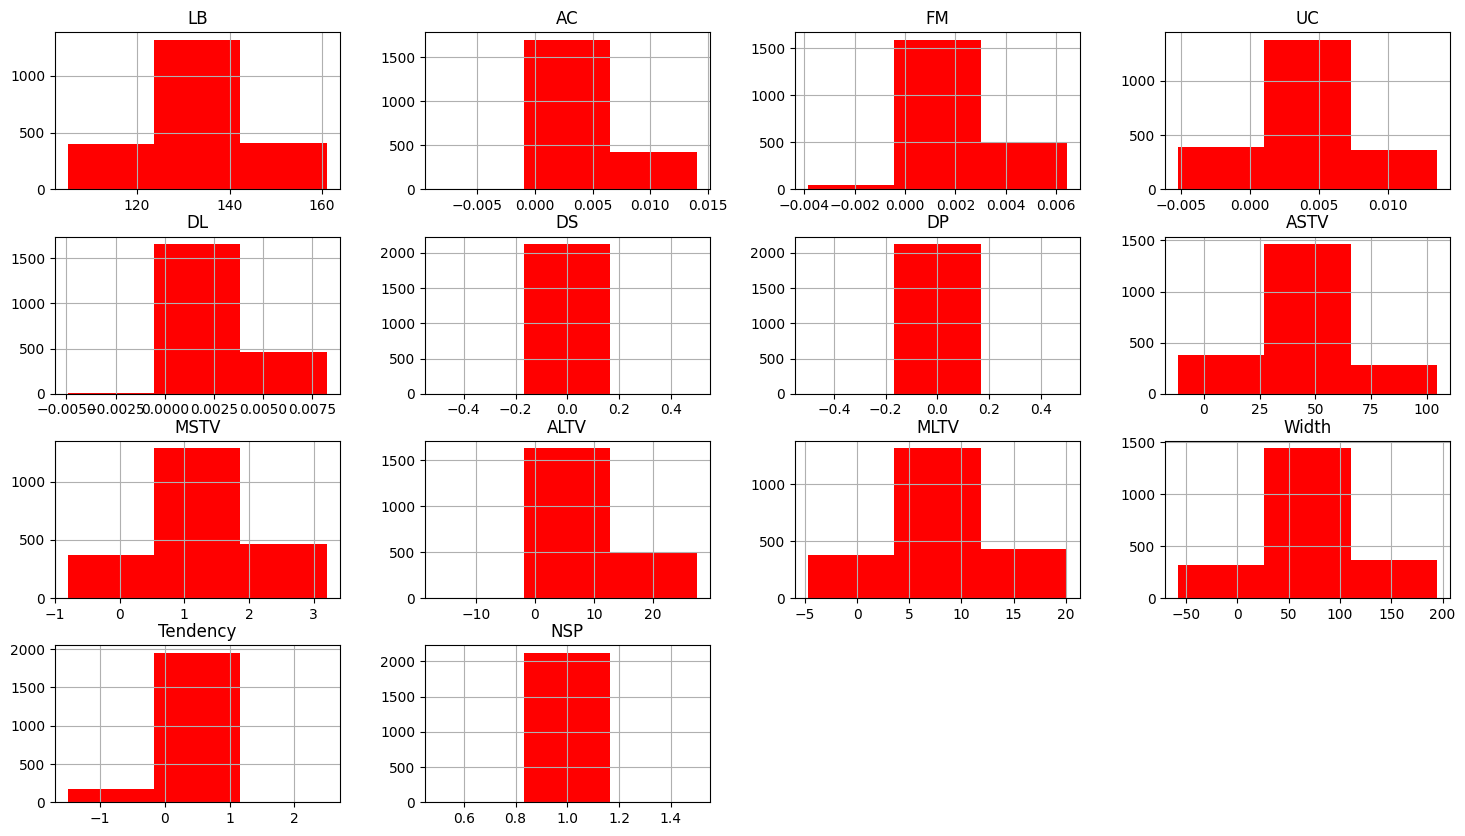

In [ ]:
df.hist(figsize=(18,10),bins=3,color='red')
plt.show()

#Boxplot

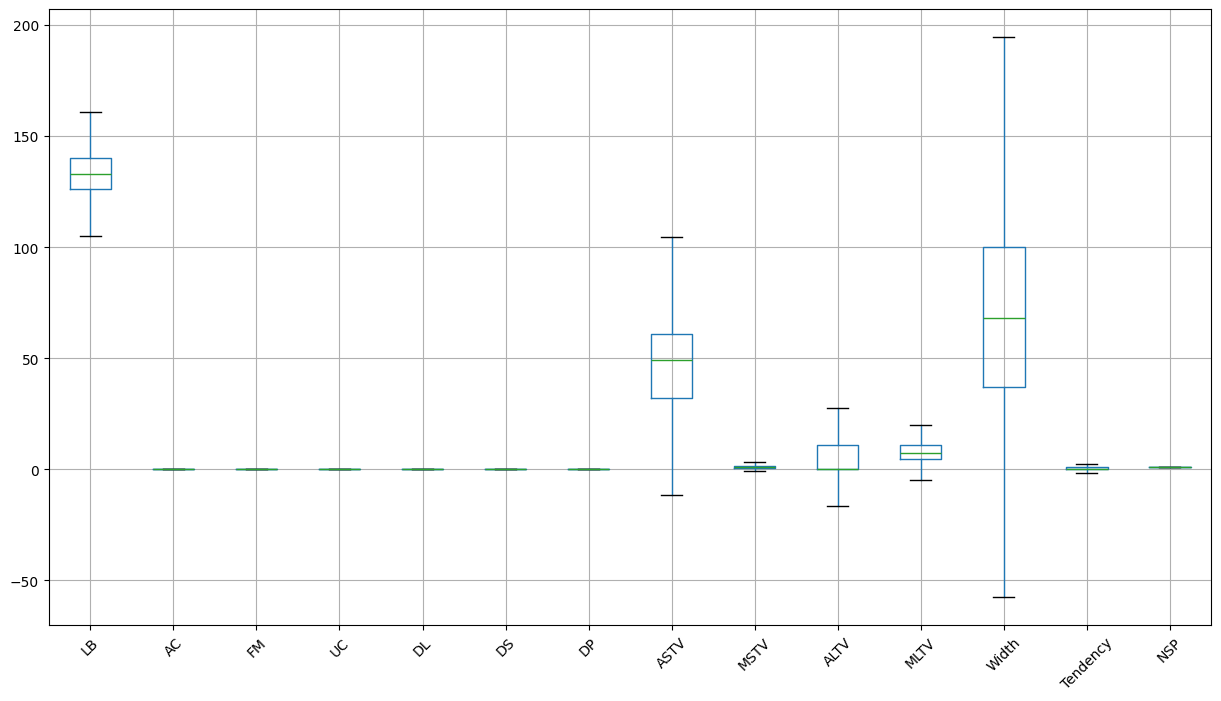

In [ ]:
df.boxplot(figsize=(15,8))
plt.xticks(rotation=45)
plt.show()

# Bar chart or Pie chart
The dataset contains only numerical variables; therefore, bar charts or pie charts for categorical variables were not applicable.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2126 entries, 0 to 2125
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   LB        2126 non-null   float64
 1   AC        2126 non-null   float64
 2   FM        2126 non-null   float64
 3   UC        2126 non-null   float64
 4   DL        2126 non-null   float64
 5   DS        2126 non-null   float64
 6   DP        2126 non-null   float64
 7   ASTV      2126 non-null   float64
 8   MSTV      2126 non-null   float64
 9   ALTV      2126 non-null   float64
 10  MLTV      2126 non-null   float64
 11  Width     2126 non-null   float64
 12  Tendency  2126 non-null   float64
 13  NSP       2126 non-null   float64
dtypes: float64(14)
memory usage: 232.7 KB


#Heatmap

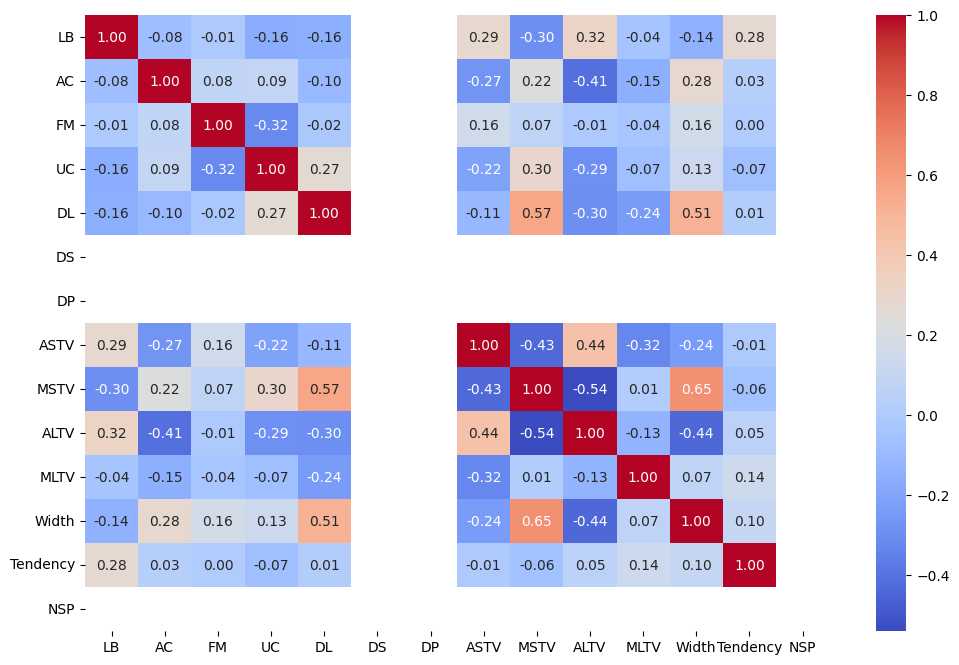

In [ ]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.show()

## Scatter plot of LB and ASTV

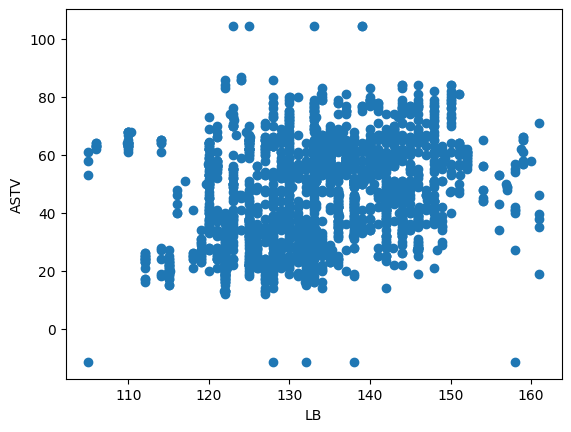

In [ ]:
plt.scatter(df["LB"], df["ASTV"])
plt.xlabel("LB")
plt.ylabel("ASTV")
plt.show()

#Scatter plot of Width and MSTV

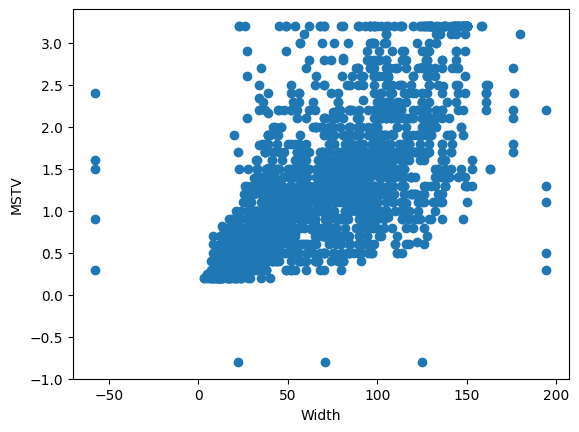

In [ ]:
plt.scatter(df["Width"], df["MSTV"])
plt.xlabel("Width")
plt.ylabel("MSTV")
plt.show()

#Violin plot

<Axes: >

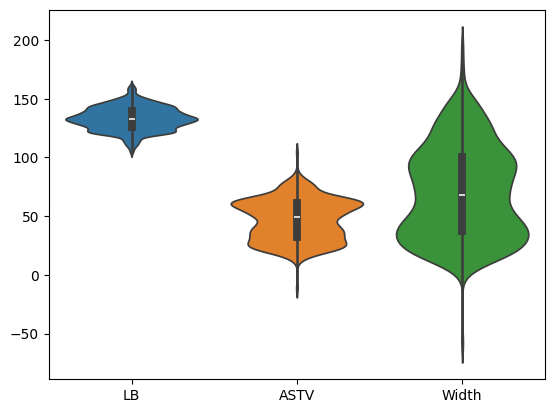

In [ ]:
sns.violinplot(data=df[['LB','ASTV','Width']])

#Pair plot

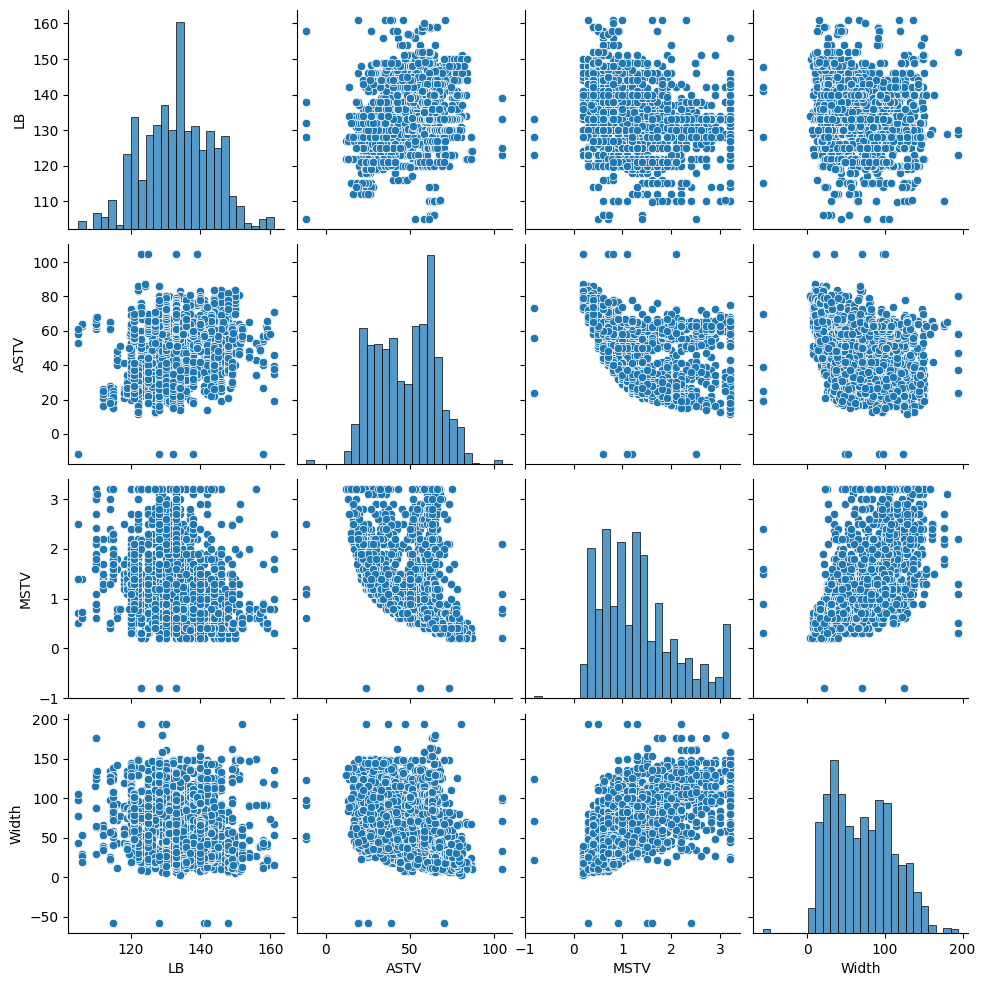

In [ ]:
sns.pairplot(df[['LB','ASTV','MSTV','Width']])

# Correlations between variable
*   MSTV and Width (r = 0.65) show a strong positive correlation.As MSTV increases, Width also tends to increase

*   MSTV and ALTV (r = -0.54) have the strongest negative correlation.As MSTV increases, ALTV tends to decrease.

*   LB–FM, Tendency–NSP, and FM–Width have weak correlation

# Trends or Patterns
The dataset does not contain any temporal variables such as date or time. Therefore, it is not possible to analyze trends or patterns over time.



# Conclusion


*   The dataset is primarily composed of numerical variables with no data type inconsistencies and also missing values were successfully handled during preprocessing.
*   The statistical summary revealed that some variables have higher variability, while others are more consistent and some variables shows positively skewness ,while others are symmetric.
*   Histograms and box plots indicated that several variables exhibit skewed distributions and contain outliers
*   The correlation analysis identified a few moderate to strong relationships between variables, whereas most variables showed weak correlations.


The findings from the exploratory analysis improve the understanding of the dataset and highlight important characteristics such as data distribution, variability, outliers, and relationships between variables. This information helps in selecting suitable preprocessing methods, improving data quality, and identifying the most relevant features for analysis. Consequently, these insights enhance the accuracy of future statistical analyses and machine learning models, leading to better decision-making.
